# mexari – Municipalities Node Classification
Explore the spatio-temporal NetworkX graph of Mexican municipalities built with the `mexari` package.
Classify each node according to their state

## 1 · Imports

In [21]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

import mexari as mx

print(f"mexari version : {mx.__version__}")
print(f"Bundled CSV    : {mx.DEFAULT_CSV}")

mexari version : 0.1.0
Bundled CSV    : /home/amilan/Insync/alessandromilanortega@outlook.com/OneDrive/Documents/UASLP/PhD/Graph-ARI/mexari/data/mortality_rates.csv


## 2 · Build the graph from a local GeoJSON

In [22]:
# Update this path to point to your local municipalities GeoJSON file.
geojson_path = Path("../Data/mexico.geojson")

if not geojson_path.exists():
    raise FileNotFoundError(
        f"Set `geojson_path` to a local GeoJSON file before running the notebook: {geojson_path}"
    )

G = mx.build_graph(geojson_path=geojson_path)

print(f"Nodes   : {G.number_of_nodes()}")
print(f"Edges   : {G.number_of_edges()}")
print(f"Dates   : {len(G.graph['dates'])}")
print(f"Density : {nx.density(G):.5f}")

Nodes   : 2475
Edges   : 7246
Dates   : 1148
Density : 0.00237


## 3 · Graph visualization

In [23]:
# Inspect a sample node
sample = G.nodes[0]
print("Node attributes:")
for k, v in sample.items():
    if k in ("mortality", "features"):
        print(f"  {k}: {type(v).__name__} with {len(v)} entries")
    else:
        print(f"  {k}: {v}")

Node attributes:
  municipality: San José de Gracia
  state: Aguascalientes
  longitude: -102.52583871928235
  latitude: 22.146634606582133
  mortality: dict with 1148 entries
  features: ndarray with 1148 entries


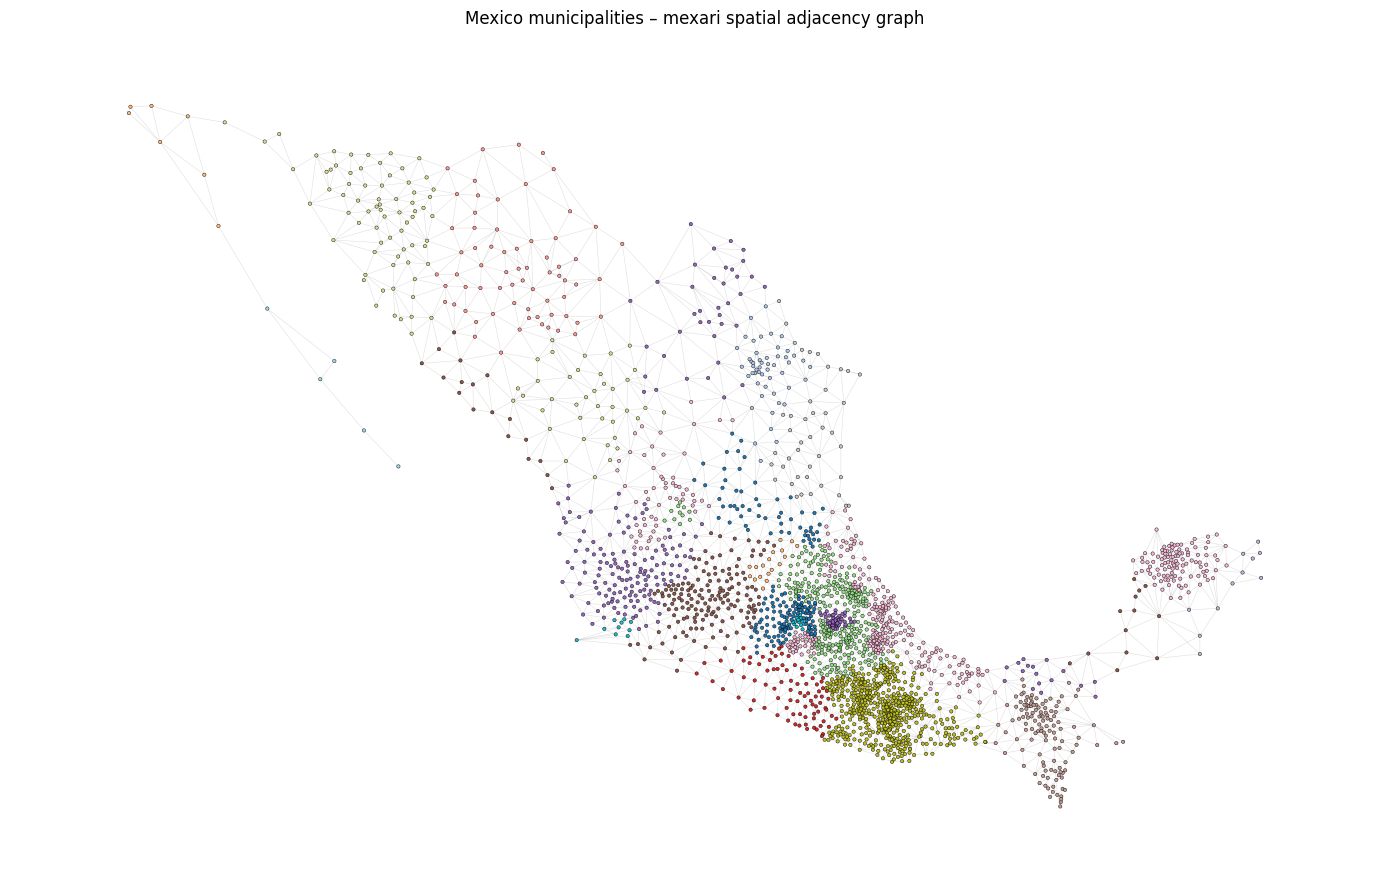

In [24]:

# 1. Get the state and position for each node
state_labels = nx.get_node_attributes(G, 'state')
pos = {n: (G.nodes[n]['longitude'], G.nodes[n]['latitude']) for n in G.nodes()}

# 2. Assign colors based on the state (32 states in Mexico)
node_colors = []
for node in G.nodes():
    state = state_labels[node]
    # Simple color mapping: use the state index to assign a color
    color_index = hash(state) % 32  # Modulo to get a number between 0 and 31
    node_colors.append(plt.cm.tab20(color_index / 32))  # Use a colormap for better visualization

fig, ax = plt.subplots(figsize=(14, 9))

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, edge_color="gray", width=0.4)
nc = nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_size=6,
    node_color=node_colors,
    edgecolors="black",
    linewidths=0.3,)

ax.set_title(
    "Mexico municipalities – mexari spatial adjacency graph"
)

ax.axis("off")
plt.tight_layout()
plt.show()

In [25]:
# %pip install torch --index-url https://download.pytorch.org/whl/cu128

In [26]:
import torch

print(torch.__version__)

2.11.0+cu128


## 4 · Get the edge list of the Municipalities network and transform it into `torch.LongTensor`.

In [27]:
def graph_to_edge_list(G):

  edge_list = []

  edge_list = list(G.edges())

  # OPTIONAL: Convert the undirected graph to a directed one first.
  # This automatically duplicates every edge in the reverse direction.
  # edge_list = list(G.to_directed().edges())

  return edge_list

def edge_list_to_tensor(edge_list):

  edge_index = torch.tensor([])

  # 1. Convert the list of tuples into a PyTorch tensor.
  #    We explicitly use dtype=torch.long because PyTorch relies on 64-bit integers for indices.
  # 2. The default shape will be [len(edge_list), 2]. 
  # 3. We use .T to transpose it to the required [2, len(edge_list)] format (also known as COO format).
  edge_index = torch.tensor(edge_list, dtype=torch.long).T

  return edge_index

edge_list = graph_to_edge_list(G)
edge_index = edge_list_to_tensor(edge_list)
print("The edge_index tensor has shape {}".format(edge_index.shape))

The edge_index tensor has shape torch.Size([2, 7246])


In [28]:
print(edge_index.t())

tensor([[   0, 2455],
        [   0,    6],
        [   0,   10],
        ...,
        [2465, 2469],
        [2468, 2469],
        [2471, 2473]])


## 5. Node Embedding Learning

In [29]:
# # Create a Feature Matrix (X) for the nodes
# # For simplicity, we will use the 'latitude' and 'longitude' attributes as the node features.
# node_features = []
# for node in G.nodes():
#     latitude = G.nodes[node].get("latitude", 0)  # Default to 0 if latitude is missing
#     longitude = G.nodes[node].get("longitude", 0)  # Default to 0 if longitude is missing
#     node_features.append([latitude, longitude])  # Create a 2D feature vector

# X = torch.tensor(node_features, dtype=torch.float)
# print("The feature matrix X has shape {}".format(X.shape))


In [30]:
# Create a Feature Matrix (X) for the nodes
# For simplicity, we will use a one-hot encoding feature vector for each node, where the feature dimension equals the number of nodes in the graph.
num_nodes = G.number_of_nodes()
X = torch.eye(num_nodes)

print("The feature matrix X has shape {}".format(X.shape))

The feature matrix X has shape torch.Size([2475, 2475])


### Node Embadding Visualization

In [31]:
# !pip install scikit-learn

In [32]:
# Helper function for visualization.
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Visualization function for NX graph or PyTorch tensor
def visualize(h, color, epoch=None, loss=None, accuracy=None):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])

    if torch.is_tensor(h):
        h_2d = TSNE(n_components=2).fit_transform(h.detach().numpy())
        # h = h.detach().cpu().numpy()
        plt.scatter(h_2d[:, 0], h_2d[:, 1], s=70, c=color, cmap="tab20")
        if epoch is not None and loss is not None and accuracy['train'] is not None and accuracy['val'] is not None:
            plt.xlabel((f'Epoch: {epoch}, Loss: {loss.item():.4f} \n'
                       f'Training Accuracy: {accuracy["train"]*100:.2f}% \n'
                       f' Validation Accuracy: {accuracy["val"]*100:.2f}%'),
                       fontsize=16)
    else:
        nx.draw_networkx(h, pos=nx.spring_layout(h, seed=42), with_labels=True,
                         node_color=color, cmap="tab20")
    plt.show()

## 6. Implementing Graph Neural Networks (GNNs)

In [33]:
# !pip install torch_geometric

In [34]:
import torch
from torch.nn import Linear
from torch_geometric.nn import GCNConv


NUM_FEATURES = X.shape[1]
NUM_CLASSES = 32  # We want to classify nodes into their respective states (32 states in Mexico)

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        torch.manual_seed(1234)
        self.conv1 = GCNConv(NUM_FEATURES, 512)
        self.conv2 = GCNConv(512, 512)
        self.conv3 = GCNConv(512, 256)
        self.conv4 = GCNConv(256, 128)
        self.conv5 = GCNConv(128, 64) # Final GNN embedding space.
        self.classifier = Linear(64, NUM_CLASSES)  # Classifier to predict the state from the GNN embedding.
    
    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = h.tanh()
        h = self.conv2(h, edge_index)
        h = h.tanh()
        h = self.conv3(h, edge_index)
        h = h.tanh()
        h = self.conv4(h, edge_index)
        h = h.tanh()
        h = self.conv5(h, edge_index)
        h = h.tanh()  # Final GNN embedding space.

        # Apply a final (linear) classifier.
        out = self.classifier(h)

        return out, h

model = GCN()
print(model)

GCN(
  (conv1): GCNConv(2475, 512)
  (conv2): GCNConv(512, 512)
  (conv3): GCNConv(512, 256)
  (conv4): GCNConv(256, 128)
  (conv5): GCNConv(128, 64)
  (classifier): Linear(in_features=64, out_features=32, bias=True)
)


Embedding shape: [2475, 64]


/tmp/ipykernel_191242/866749292.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(h_2d[:, 0], h_2d[:, 1], s=70, c=color, cmap="tab20")


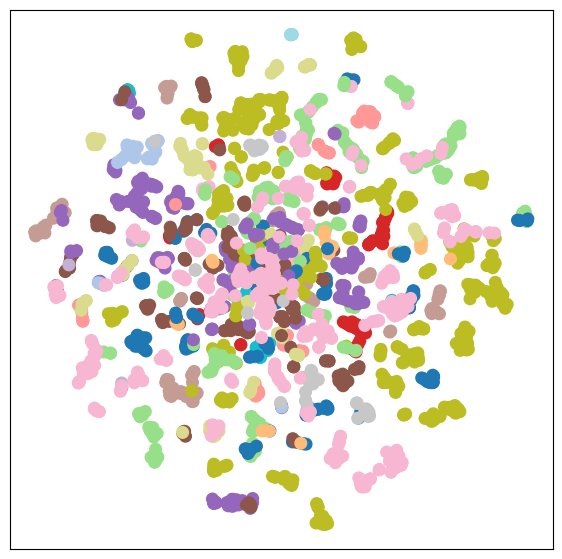

In [ ]:
model = GCN()

_, h = model(X, edge_index)
print(f'Embedding shape: {list(h.shape)}')

visualize(h, color=node_colors)

In [ ]:
_, h = model(X, edge_index)
print(f'Embedding shape: {list(h.shape)}')

visualize(h, color=node_colors)

In [36]:
# Build a unique list of state labels for all nodes, 
# represent each state as a unique integer, and create a label tensor (y) for node classification.
state_labels = []
for node in G.nodes():
    state = G.nodes[node].get("state", "Unknown")  # Default to "Unknown" if state is missing
    state_labels.append(state)
unique_states = list(set(state_labels))
state_to_index = {state: idx for idx, state in enumerate(unique_states)}
Y = torch.tensor([state_to_index[state] for state in state_labels], dtype=torch.long)
print("The label tensor y has shape {}".format(Y.shape))

The label tensor y has shape torch.Size([2475])


In [37]:
# Create train/val/test masks for node classification
num_nodes = X.shape[0]
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

# Randomly select 60% of the nodes for training, 20% for validation, and 20% for testing
num_train = int(0.6 * num_nodes)
num_val = int(0.2 * num_nodes)
num_test = int(0.2 * num_nodes)
all_indices = torch.randperm(num_nodes)
train_indices = all_indices[:num_train]
val_indices = all_indices[num_train:num_train + num_val]
test_indices = all_indices[num_train + num_val:num_train + num_val + num_test]
train_mask[train_indices] = True
val_mask[val_indices] = True
test_mask[test_indices] = True

<IPython.core.display.Javascript object>

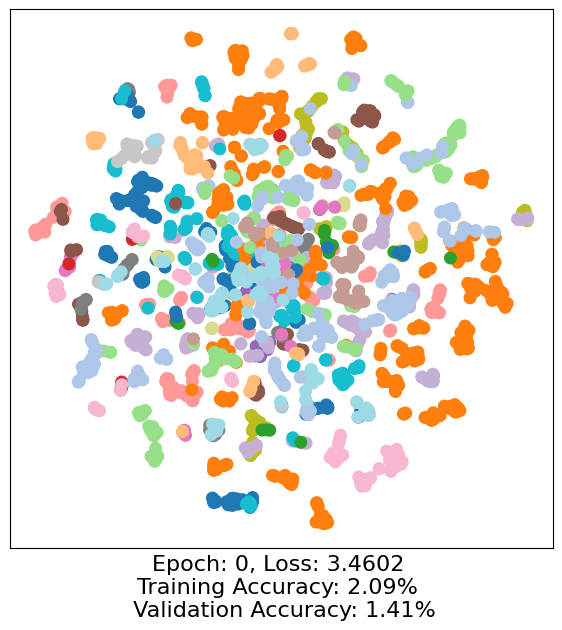

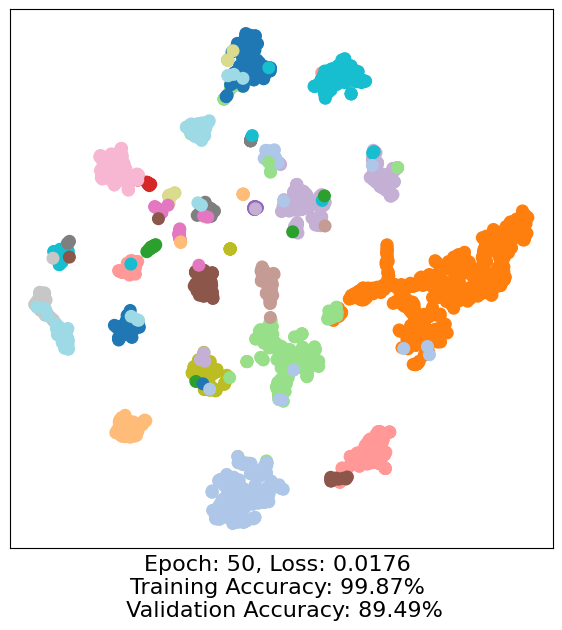

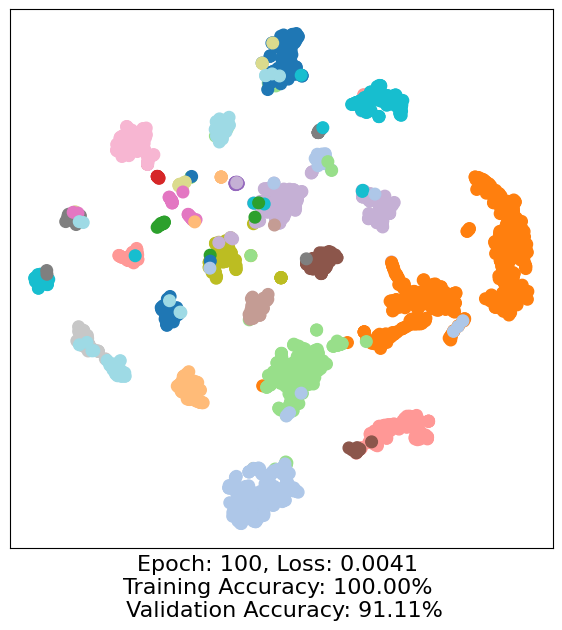

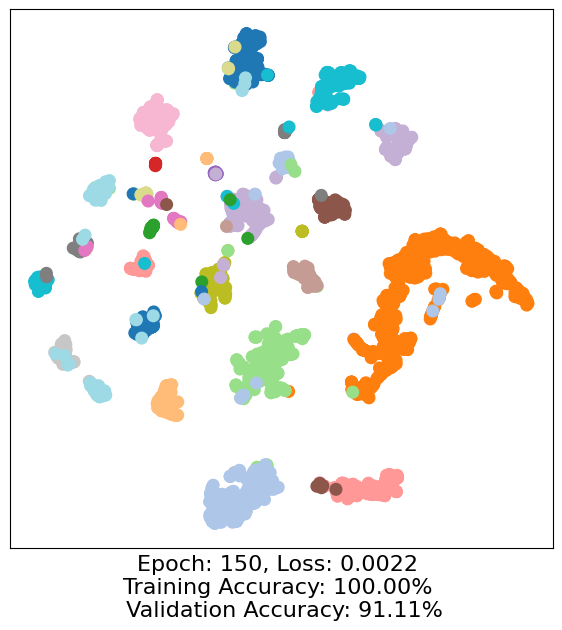

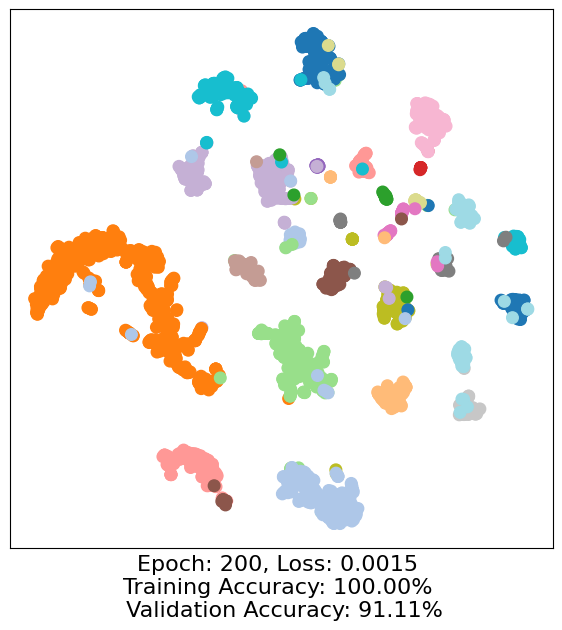

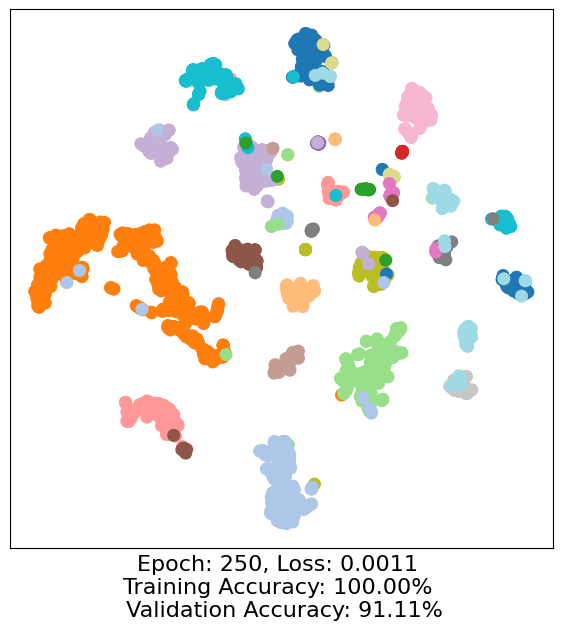

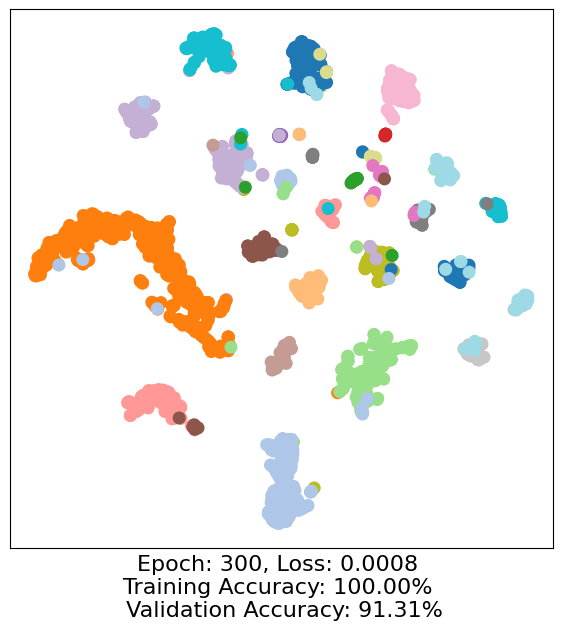

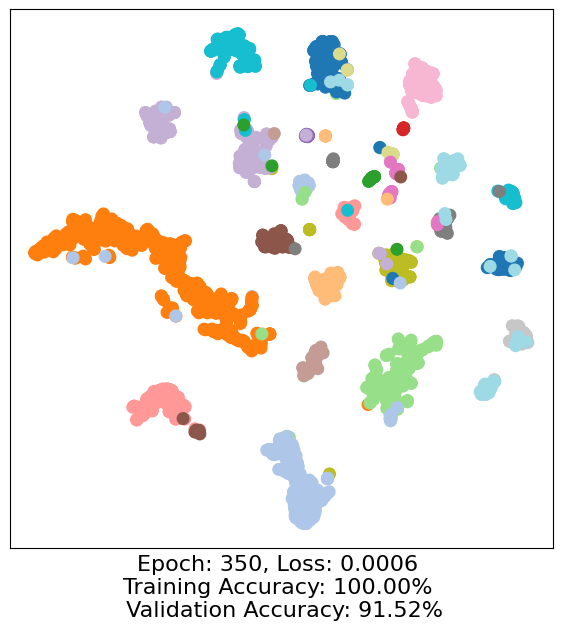

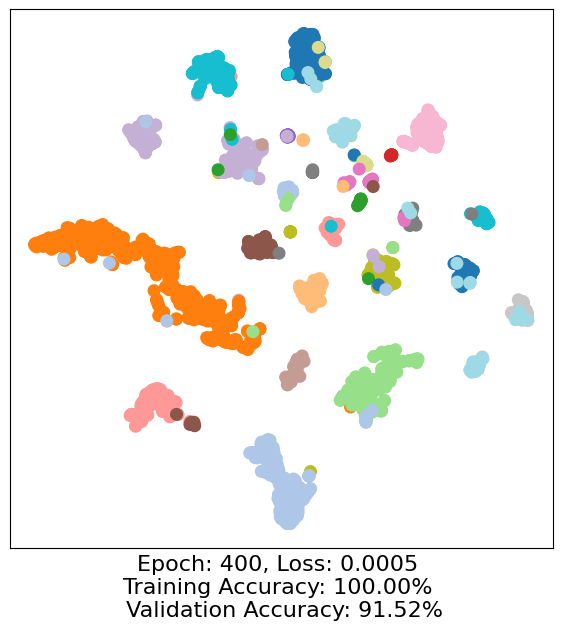

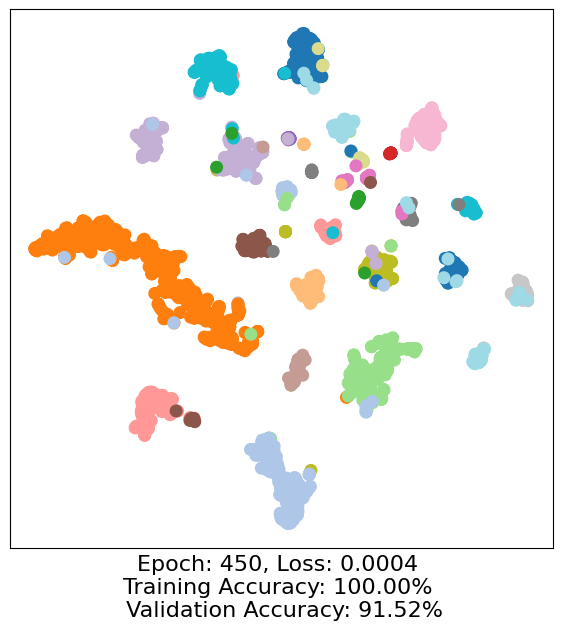

In [38]:
import time
from IPython.display import Javascript  # Restrict height of output cell.
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 430})'''))

model = GCN()
criterion = torch.nn.CrossEntropyLoss()  # Define loss criterion.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Define optimizer.

def train(X, Y, edge_index):
    optimizer.zero_grad()  # Clear gradients.
    out, h = model(X, edge_index)  # Perform a single forward pass.
    loss = criterion(out[train_mask], Y[train_mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.

    accuracy = {}
    # Calculate training accuracy on our four examples
    predicted_classes = torch.argmax(out[train_mask], axis=1) # [0.6, 0.2, 0.7, 0.1] -> 2
    target_classes = Y[train_mask]
    accuracy['train'] = torch.mean(
        torch.where(predicted_classes == target_classes, 1, 0).float())

    # Calculate validation accuracy on the whole graph
    predicted_classes = torch.argmax(out[val_mask], axis=1)
    target_classes = Y[val_mask]
    accuracy['val'] = torch.mean(
        torch.where(predicted_classes == target_classes, 1, 0).float())

    return loss, h, accuracy

for epoch in range(500):
    loss, h, accuracy = train(X, Y, edge_index)
    # Visualize the node embeddings every 50 epochs
    if epoch % 50 == 0:
        visualize(h, color=Y, epoch=epoch, loss=loss, accuracy=accuracy)
        time.sleep(0.3)

In [39]:
# Calculate test accuracy on the test nodes

out, h = model(X, edge_index)  # Get the final output from the model after training.

predicted_classes = torch.argmax(out[test_mask], axis=1)
target_classes = Y[test_mask]
test_accuracy = torch.mean(torch.where(predicted_classes == target_classes, 1, 0).float())
print("Test Accuracy: {:.4f}".format(test_accuracy))

Test Accuracy: 0.9071


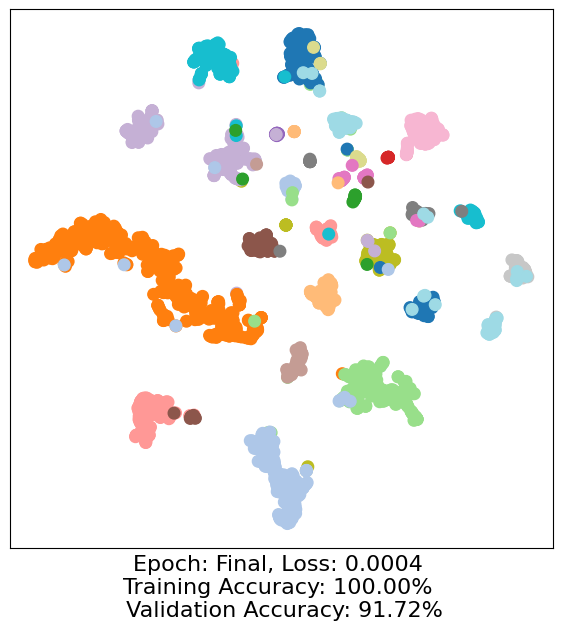

In [40]:
# Plot the final node embeddings colored by their true state labels
visualize(h, color=Y, epoch="Final", loss=loss, accuracy=accuracy)

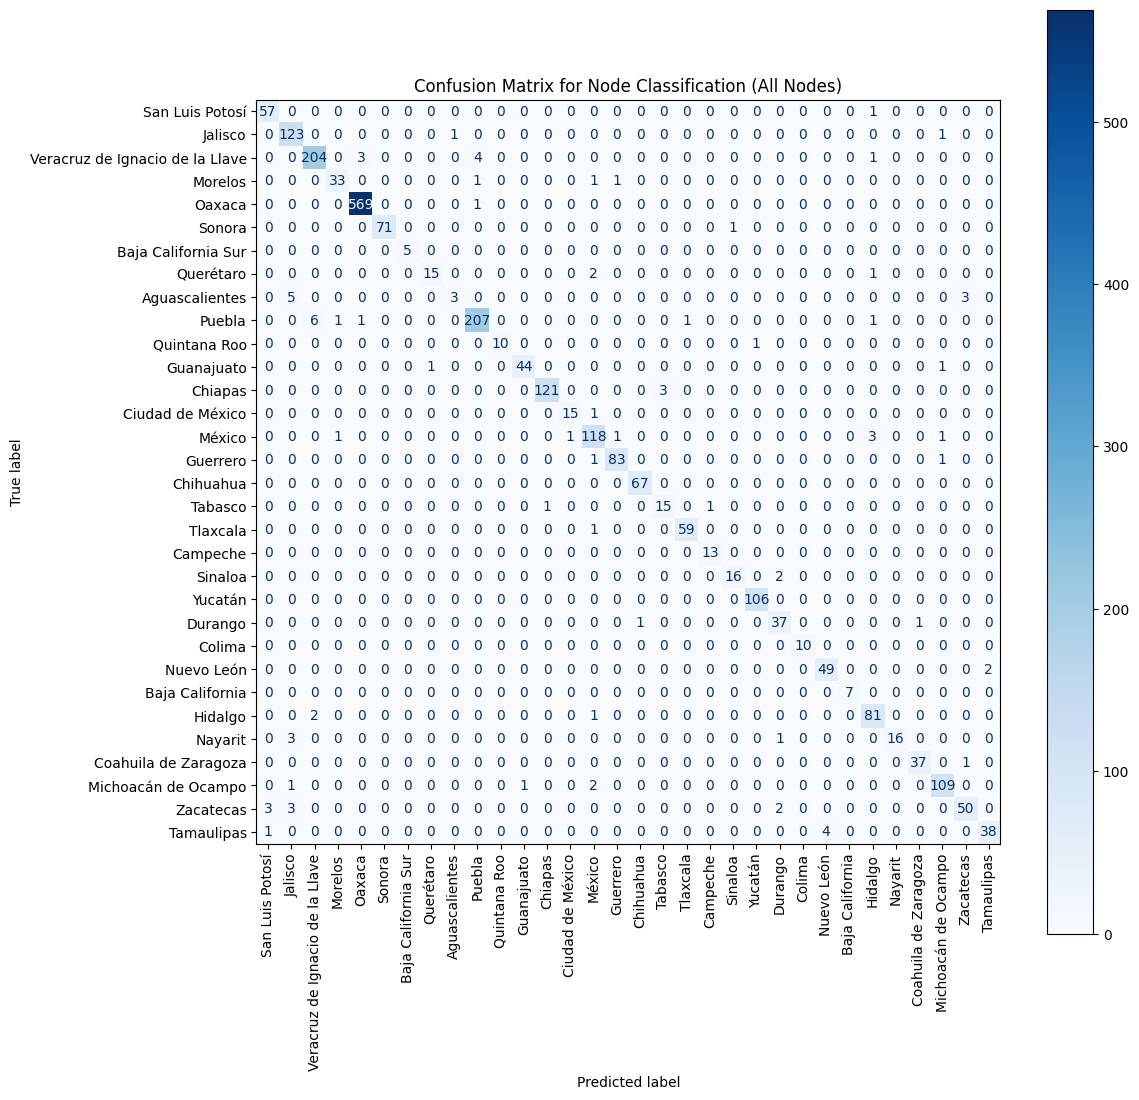

In [41]:
# Build a Confusion Matrix for the whole graph (not just the test nodes) to see how well the model is classifying each state.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
predicted_classes = torch.argmax(out, axis=1).numpy()  # Get predicted classes for all nodes
true_classes = Y.numpy()  # Get true classes for all nodes
cm = confusion_matrix(true_classes, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_states)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90)
plt.title("Confusion Matrix for Node Classification (All Nodes)")
plt.show()

In [44]:
# Print the scores for the entire graph, including the overall accuracy and F1-score for each state.
from sklearn.metrics import classification_report
print("Classification Report for Node Classification (All Nodes):")
print(classification_report(true_classes, predicted_classes, target_names=unique_states))


Classification Report for Node Classification (All Nodes):
                                 precision    recall  f1-score   support

                San Luis Potosí       0.93      0.98      0.96        58
                        Jalisco       0.91      0.98      0.95       125
Veracruz de Ignacio de la Llave       0.96      0.96      0.96       212
                        Morelos       0.94      0.92      0.93        36
                         Oaxaca       0.99      1.00      1.00       570
                         Sonora       1.00      0.99      0.99        72
            Baja California Sur       1.00      1.00      1.00         5
                      Querétaro       0.94      0.83      0.88        18
                 Aguascalientes       0.75      0.27      0.40        11
                         Puebla       0.97      0.95      0.96       217
                   Quintana Roo       1.00      0.91      0.95        11
                     Guanajuato       0.98      0.96      0.97  